# Deep Learning Text Generation Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**


In this notebook, we build three recurrent sequence models- Vanilla RNN, LSTM and GRU - on the same text corpus and compare:
- How fast each model learns(training loss curve)
- The quality of text each model generates
- The trade-offs between simplicity and memory capacity

**Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# Problem Statement
To design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

**1] To import required libraries**

We use Tensorflow/Keras for building the models and NumPy/Matplotlib for data handling and visualization.

In [59]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

**2] Original text corpus (Baseline)**
This is the starter corpus that is provided. (Corpus is simply a body of text that we feed to the model, the model learns patterns from it).

In [60]:
original_corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print("Original Corpus: ")
print(original_corpus)

Original Corpus: 

deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

**3] Text Cleaning, Tokenization and sequence creation**

We perform the following: Cleaning, Tokenisation, N-gram sequences, padding and X/y split.
>We use n-grams because we want the model to practise predicting the next word given everything before it. Creating all prefix sub-sequences gives the model many training examples from a small corpus.

In [61]:
corpus_cleaned=original_corpus.lower().strip()
lines=[line.strip() for line in corpus_cleaned.split('\n') if line.strip()]
print(f"Number of sentences: {len(lines)}")
print("Lines: ",lines)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
print("Word -> Index Mapping: ", tokenizer.word_index)

input_sequences = []
for line in corpus_cleaned.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)
print(f"Total n-gram sequence created: {len(input_sequences)}")
print('Example (first 3 sequences before padding): ',input_sequences[:3])

max_len = max(len(seq) for seq in input_sequences)
print(f"Maximum sequence length: {max_len}")
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
print("Shape after padding: ",input_sequences.shape)
print("\nExample padded sequence (first row): ",input_sequences[0])

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Number of sentences: 6
Lines:  ['deep learning is transforming artificial intelligence', 'recurrent neural networks are useful for sequential data', 'lstm helps remember long term dependencies', 'gru is faster and simpler than lstm', 'text generation models predict the next word', 'deep learning models can generate meaningful sentences']
Vocabulary size: 37
Word -> Index Mapping:  {'deep': 1, 'learning': 2, 'is': 3, 'lstm': 4, 'models': 5, 'transforming': 6, 'artificial': 7, 'intelligence': 8, 'recurrent': 9, 'neural': 10, 'networks': 11, 'are': 12, 'useful': 13, 'for': 14, 'sequential': 15, 'data': 16, 'helps': 17, 'remember': 18, 'long': 19, 'term': 20, 'dependencies': 21, 'gru': 22, 'faster': 23, 'and': 24, 'simpler': 25, 'than': 26, 'text': 27, 'generation': 28, 'predict': 29, 'the': 30, 'next': 31, 'word': 32, 'can': 33, 'generate': 34, 'meaningful': 35, 'sentences': 36}
Total n-gram sequence created: 35
Example (first 3 sequences before padding):  [[1, 2], [1, 2, 3], [1, 2, 3, 6]

**4] To build the three models**
Common architecture for all three:
- Embedding layer
- Recurrent Layer(RNN/LSTM/GRU)
- Dense(softmax)

We use sparse_categorical_crossentropy because our targets are integer class indices so  it saves memory and computation.

# Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [62]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
],name="Vanilla_RNN")

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])


rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
rnn_model.summary()
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_27 (Embedding)        │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,393 (114.82 KB)

 Trainable params: 9,797 (38.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,596 (76.55 KB)

Vanilla RNN training completed


# Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [63]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
],name="LSTM_Model")

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
lstm_model.summary()
print("LSTM training completed")

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_28 (Embedding)        │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,265 (333.07 KB)

 Trainable params: 28,421 (111.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,844 (222.05 KB)

LSTM training completed


# Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [64]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
],name='GRU_Model')

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
gru_model.summary()
print("GRU training completed")

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_29 (Embedding)        │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,217 (262.57 KB)

 Trainable params: 22,405 (87.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,812 (175.05 KB)

GRU training completed


## Compare Training Loss

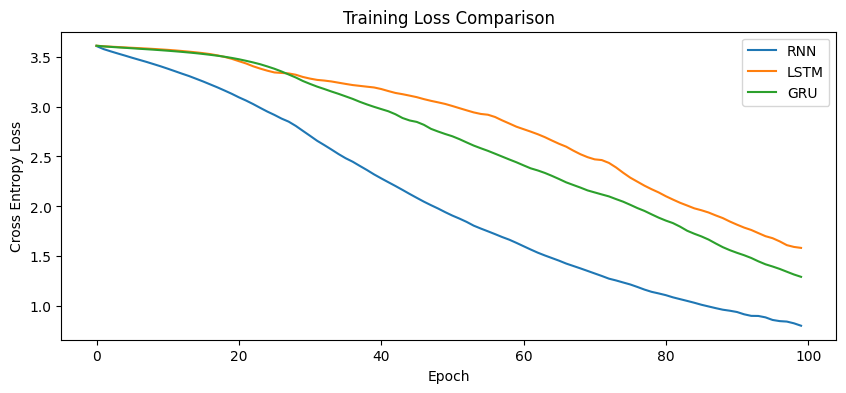

In [65]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

We notice that LSTM and GRU both handle long-range context better than Vanilla RNN because their geating mechanisms protect gradients from vanishing during backpropagation through time.

# Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

We take a seed phrase, tokenise and pad it to match the model input shape, get the probability vector and pick the most likely next word. We then map that index back to the actual word using the tokeniser's word index and then append the word to the seed and repeat.

In [66]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## Generate Text Samples

In [67]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning is transforming artificial intelligence meaningful
GRU : deep learning models can generate meaningful sentences


#  Student Learning Tasks
###  Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

#Task 1: Replacing the corpus with a custom paragraph

Training on different text teaches the model different vocabulary and sentence patterns. A longer or more varied corpus also gives more training examples.

We replace the original 6 line corpus with a custom paragraph about ML and data science.

In [68]:
custom_corpus='''machine learning enables computers to learn from data without being explicitly programmed
neural networks are inspired by the human brain
data science combines statistics and domain knowledge
supervised learning uses labelled examples to train a model
unsupervised learning finds hidden patterns in unlabelled data
feature engineering transforms raw data into useful inputs for models
gradient descent is an optimisation algorithm used to minimize loss
overfitting happens when a model learns noise instead of the true pattern
regularisation techniques like dropout help prevent overfitting
deep neural networks can learn complex representations from large datasets'''

custom_lines=[line.strip() for line in custom_corpus.lower().strip().split('\n') if line.strip()]
print(f"Custom corpus has {len(custom_lines)} sentences")
for i,line in enumerate(custom_lines,1):
  print(f" {i}, {line}")

custom_tokenizer=Tokenizer()
custom_tokenizer.fit_on_texts(custom_lines)
custom_total_words=len(custom_tokenizer.word_index)+1
print(f"Custom vocabulary size: {custom_total_words} unique words")
custom_sequences=[]
for line in custom_lines:
  token_list=custom_tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    custom_sequences.append(token_list[:i+1])
custom_max_len=max(len(s) for s in custom_sequences)
custom_sequences=pad_sequences(custom_sequences,maxlen=custom_max_len,
                               padding='pre')
X_custom=custom_sequences[:,:-1]
y_custom=custom_sequences[:,-1]
print(f"X_custom shape: {X_custom.shape}")
print(f"y_custom shape: {y_custom.shape}")

Custom corpus has 10 sentences
 1, machine learning enables computers to learn from data without being explicitly programmed
 2, neural networks are inspired by the human brain
 3, data science combines statistics and domain knowledge
 4, supervised learning uses labelled examples to train a model
 5, unsupervised learning finds hidden patterns in unlabelled data
 6, feature engineering transforms raw data into useful inputs for models
 7, gradient descent is an optimisation algorithm used to minimize loss
 8, overfitting happens when a model learns noise instead of the true pattern
 9, regularisation techniques like dropout help prevent overfitting
 10, deep neural networks can learn complex representations from large datasets
Custom vocabulary size: 79 unique words
X_custom shape: (83, 11)
y_custom shape: (83,)


#Task 2,3,4,5 : Upscaling Embedding Dimensions, Expanding Training to 200 Epochs, Widening Hidden layers and to Generate 10 words per prompt

- A larger embedding dimension means each word is represented by a longer vector, which can capture more nuanced semantic relationships between words. However, more parameters lead to slightly slow training but potentially better representations.

- More epochs give the model more chances to see and learn from the training data. On a small corpus like ours, 200 epochs often drives loss lower. But we should be aware of overfitting as the model may memorise the corpus rather than generalise.

- Widening hidden layers leads to more hidden units that as a result create more parameters, which means it gives greater capacity to model complex patterns.

- Generating more words tests whether the model can maintain coherent context across a longer continuation. Gated models like LSTM/GRU perform better here.

In [69]:
def build_model(model_type,vocab_size,max_length,embedding_dim=64,hidden_units=128):
  """
  Factory function that builds RNN/LSTM/GRU model.
  Accepts embedding_dim and hidden_units as parameters so we can easily experiment with different sizes"""
  model=Sequential(name=f"Custom_{model_type}")
  model.add(Input(shape=(max_length-1,)))
  model.add(Embedding(input_dim=vocab_size,output_dim=embedding_dim))
  if model_type=="RNN":
    model.add(SimpleRNN(hidden_units))
  elif model_type=="LSTM":
    model.add(LSTM(hidden_units))
  elif model_type=="GRU":
    model.add(GRU(hidden_units))
  model.add(Dense(vocab_size,activation='softmax'))
  model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
  return model
custom_rnn=build_model("RNN",custom_total_words,custom_max_len)
custom_lstm=build_model("LSTM",custom_total_words,custom_max_len)
custom_gru=build_model("GRU",custom_total_words,custom_max_len)
print("Custom models built successfully.")
print("Embedding dimension : 64(initially was 32)")
print("Hidden Units : 128(initially was 64)")

print("\n"+"=="*70)
print("Custom RNN Model Summary")
print("="*70)
custom_rnn.summary()
print("\n"+"=="*70)
print("Custom LSTM Model Summary")
print("="*70)
custom_lstm.summary()
print("\n"+"=="*70)
print("Custom GRU Model Summary")
print("="*70)
custom_gru.summary()

Custom models built successfully.
Embedding dimension : 64(initially was 32)
Hidden Units : 128(initially was 64)

Custom RNN Model Summary


Model: "Custom_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ (None, 11, 64)         │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 79)             │        10,191 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,951 (156.06 KB)

 Trainable params: 39,951 (156.06 KB)

...

Model: "Custom_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_32 (Embedding)        │ (None, 11, 64)         │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 79)             │        10,191 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,743 (350.56 KB)

 Trainable params: 89,743 (350.56 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
EPOCHS=200
print("Training Custom RNN(200 epochs, embedding=64,hidden=128)....")
c_rnn_history=custom_rnn.fit(X_custom,y_custom,epochs=200,verbose=0)
print(f"Final Loss: {c_rnn_history.history['loss'][-1]:.4f} |"
f"Accuracy: {c_rnn_history.history['accuracy'][-1]:.4f}")
print("Training Custom LSTM....")
c_lstm_history=custom_lstm.fit(X_custom,y_custom,epochs=200,verbose=0)
print(f"Final Loss: {c_lstm_history.history['loss'][-1]:.4f} |"
f"Accuracy: {c_lstm_history.history['accuracy'][-1]:.4f}")
print("Training Custom GRU....")
c_gru_history=custom_gru.fit(X_custom,y_custom,epochs=200,verbose=0)
print(f"Final Loss: {c_gru_history.history['loss'][-1]:.4f} |"
f"Accuracy: {c_gru_history.history['accuracy'][-1]:.4f}")
print("\nAll custom models trained.")


Training Custom RNN(200 epochs, embedding=64,hidden=128)....
Final Loss: 0.0105 |Accuracy: 1.0000
Training Custom LSTM....
Final Loss: 0.1589 |Accuracy: 0.9880
Training Custom GRU....
Final Loss: 0.0172 |Accuracy: 1.0000

All custom models trained.


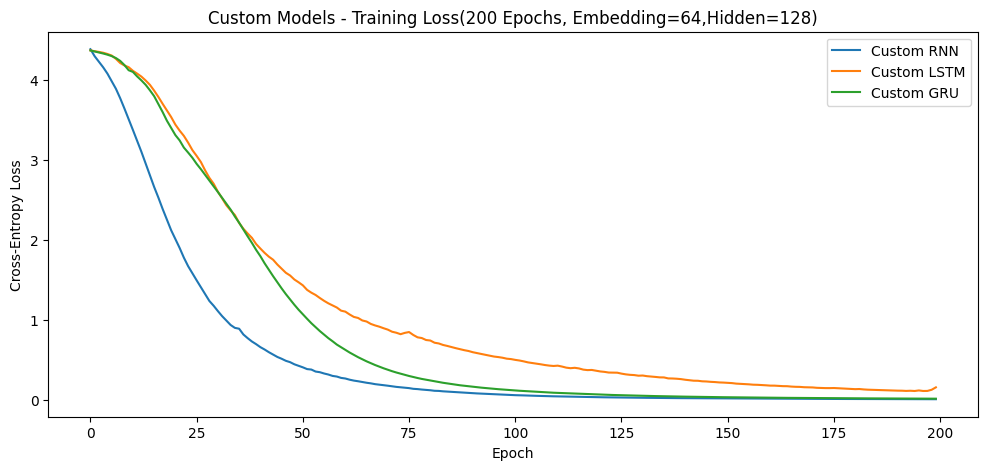

In [71]:
plt.figure(figsize=(12,5))
plt.plot(c_rnn_history.history['loss'],label='Custom RNN')
plt.plot(c_lstm_history.history['loss'],label='Custom LSTM')
plt.plot(c_gru_history.history['loss'],label='Custom GRU')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Custom Models - Training Loss(200 Epochs, Embedding=64,Hidden=128)")
plt.legend()
plt.show()

In [72]:
def generate_text_custom(model,seed_text,next_words=10):
  """
  Same logic as generate_text() but uses the custom_tokenizer and custom_max_len that match the custom models
  """
  for _ in range(next_words):
    token_list=custom_tokenizer.texts_to_sequences([seed_text])[0]
    token_list=pad_sequences([token_list],maxlen=custom_max_len-1,padding='pre')
    predicted_probs=model.predict(token_list,verbose=0)
    predicted_index=np.argmax(predicted_probs,axis=-1)[0]
    output_word=""
    for word,index in custom_tokenizer.word_index.items():
      if index==predicted_index:
        output_word=word
        break
    seed_text=seed_text+" "+output_word
  return seed_text

seed="machine learning"
print("="*70)
print(f"Seed: '{seed}' | Generating 10 words from custom models")
print("="*70)
print(f"Custom RNN: {generate_text_custom(custom_rnn,seed,10)}")
print(f"Custom LSTM: {generate_text_custom(custom_lstm,seed,10)}")
print(f"Custom GRU: {generate_text_custom(custom_gru,seed,10)}")

seed2="neural networks"
print(f"Seed2: '{seed2}' | Generating 10 words from custom models")
print("="*70)
print(f"Custom RNN: {generate_text_custom(custom_rnn,seed2,10)}")
print(f"Custom LSTM: {generate_text_custom(custom_lstm,seed2,10)}")
print(f"Custom GRU: {generate_text_custom(custom_gru,seed2,10)}")

Seed: 'machine learning' | Generating 10 words from custom models
Custom RNN: machine learning enables computers to learn from data without being explicitly programmed
Custom LSTM: machine learning enables computers to learn from data without being explicitly programmed
Custom GRU: machine learning enables computers to learn from data without being explicitly programmed
Seed2: 'neural networks' | Generating 10 words from custom models
Custom RNN: neural networks are inspired by the human brain help prevent used to
Custom LSTM: neural networks are inspired by the human brain brain brain pattern pattern
Custom GRU: neural networks are inspired by the human brain brain brain brain pattern


#SUMMARY COMPARISON

In [73]:
print("="*70)
print(f"{'Model':<12}{'Config':<30}{'Final Loss':>12}{'Final Acc':>11}")
print("-"*70)
models_info=[
    ("Vanilla RNN","Emb=32,Hidden=64,100 ep",rnn_history),
    ("LSTM","Emb=32,Hidden=64,100 ep",lstm_history),
    ("GRU","Emb=32,Hidden=64,100 ep",gru_history),
    ("Custom RNN","Emb=64,Hidden=128,200 ep",c_rnn_history),
    ("Custom LSTM","Emb=64,Hidden=128,200 ep",c_lstm_history),
    ("Custom GRU","Emb=64,Hidden=128,200 ep",c_gru_history)
]
for name,config, hist in models_info:
  loss=hist.history['loss'][-1]
  acc=hist.history['accuracy'][-1]
  print(f"{name:<12} {config:<30} {loss:>12.4f} {acc:>10.4f}")
print("="*70)

Model       Config                          Final Loss  Final Acc
----------------------------------------------------------------------
Vanilla RNN  Emb=32,Hidden=64,100 ep              0.8060     0.9143
LSTM         Emb=32,Hidden=64,100 ep              1.5850     0.5143
GRU          Emb=32,Hidden=64,100 ep              1.2953     0.8000
Custom RNN   Emb=64,Hidden=128,200 ep             0.0105     1.0000
Custom LSTM  Emb=64,Hidden=128,200 ep             0.1589     0.9880
Custom GRU   Emb=64,Hidden=128,200 ep             0.0172     1.0000


# Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory.
It is simple and fast but suffers from vanishing gradient.
- **LSTM** captures long-range grammar dependencies better. It consists of three gates(forget,input and output).
- **GRU** gives similar performance with fewer gates(reset,update) and faster training
- Larger embedding i.e 32->64 gives richer word representations.
- More hidden units (64->128) increases model capacity to learn complex patterns.
- More epochs allows more learning especially on a smaller corpus.
- Custom corpus ensures that domain-specific text means the model learns vocabulary relevant to the task.